# Intro to mapping

<div style="background-color: #f2f9e6; border: 1px solid #d2eeb4; border-radius: 4px; padding: 15px;">

<h3 style="margin-top: 0; background-color: #daeebe; padding: 5px 10px; margin: -15px -15px 15px -15px; border-radius: 4px 4px 0 0; color: #2b542c;">
    ❓ Overview
</h3>  

#### **Questions**
* How can I create maps of my gridded data?

#### **Objectives**
* Create both static and interactive plots of 1 day of SST data 
* Add features to maps (ie bathymetry, land mask, and coastlines) 
</div>

## Resources
## Main packages of use 
* [Cartopy](https://cartopy.readthedocs.io/stable/)
* [Matplotlib](https://matplotlib.org/)
* [Plotly](https://plotly.com/)

First, we are going to load some data to plot.

In [1]:
# import packages 
import requests 
import xarray as xr

# load ERDDAP URL 
url = 'https://comet.nefsc.noaa.gov/erddap/griddap/noaa_coastwatch_acspo_v2_nrt.nc?sea_surface_temperature%5B(2026-05-14T12:00:00Z):1:(2026-05-14T12:00:00Z)%5D%5B(34):1:(46)%5D%5B(-77):1:(-63)%5D,sst_gradient_magnitude%5B(2026-05-14T12:00:00Z):1:(2026-05-14T12:00:00Z)%5D%5B(34):1:(46)%5D%5B(-77):1:(-63)%5D'
url_new = requests.get(url,verify=False).content
ds = xr.open_dataset(url_new)

/Users/kimberly.hyde/miniconda3/envs/satprocessing/lib/python3.11/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'comet.nefsc.noaa.gov'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(


If you want to visualize the data quickly, xarray has a built in function ```.plot()``` that can give you a quick and dirty plot. *Note that when plotting, it can only be 2-D here, you need to specify a timestep to plot.*

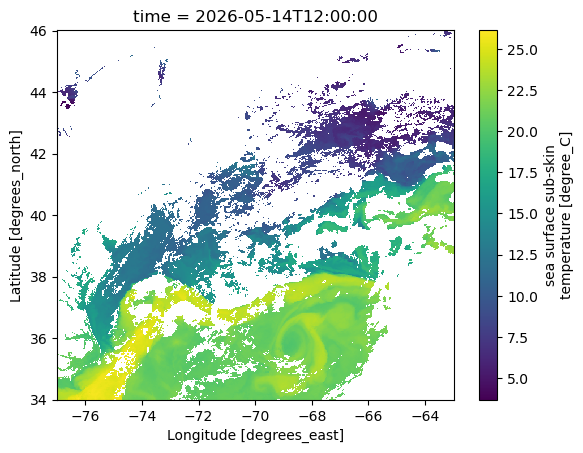

In [2]:
ds.sea_surface_temperature[0].plot()

If you want a more sophisticated static plot, you can use matplotlib to create a map with some extra features. 
We will add a landmask, coastlines, and the 200 m isobath. 

Text(0.5, 1.0, 'Sea surface temperature\n2026-05-14 12:00:00')

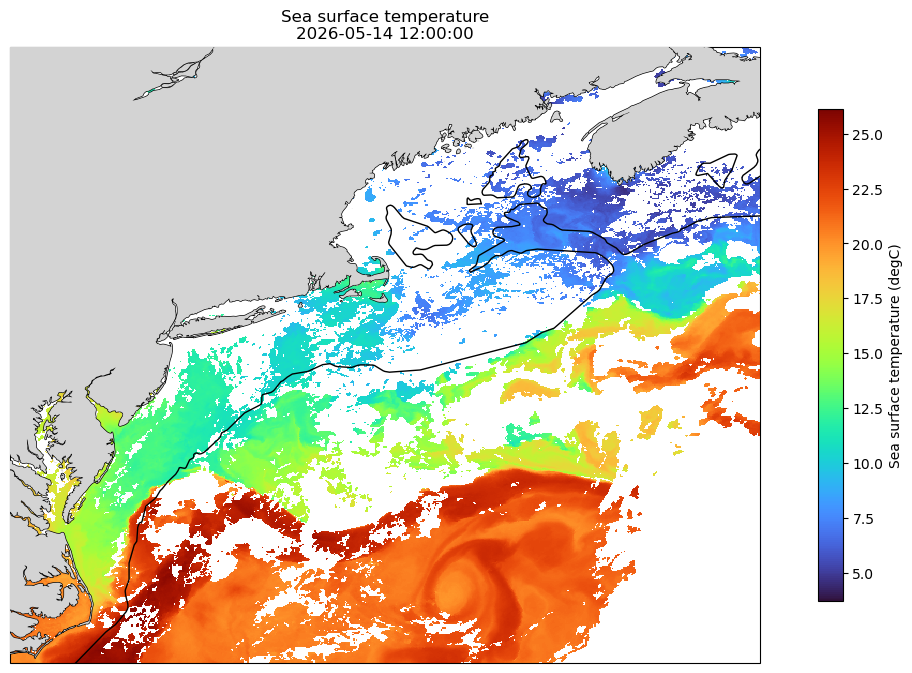

In [3]:
import matplotlib.pyplot as plt
import cartopy
import pandas as pd
from shapely.ops import unary_union
import cartopy.feature as cfeature
bathym = cfeature.NaturalEarthFeature(name='bathymetry_K_200', scale='10m', category='physical')
bathym = unary_union(list(bathym.geometries()))

fig = plt.figure(figsize=(15, 8)) #set figure size
map_projection = cartopy.crs.PlateCarree() #set map projection
ax = plt.axes(projection=map_projection) 
im = plt.pcolormesh(ds.longitude,ds.latitude,ds.sea_surface_temperature[0],cmap='turbo')
cb=plt.colorbar(im,shrink=0.8,label='Sea surface temperature (degC)')
ax.add_feature(cartopy.feature.COASTLINE, linewidth=1) #add coastlines
ax.add_feature(cartopy.feature.LAND, zorder=100, facecolor='lightgrey') #add land mask 
ax.add_geometries(bathym, facecolor='none', edgecolor='black', crs=cartopy.crs.PlateCarree()) #add bathymetry line
ax.set_extent([-77, -63, 34.5, 46])
ax.set_title(f'Sea surface temperature\n{pd.to_datetime(ds.time[0].values)}')


We can also create interactive plots using plotly (and other packages). Here we will create just a simple interactive SST plot where you can hover over a pixel and see the location and SST. Note the difference in syntax between using matplotlib vs plotly. 

In [4]:
import plotly.express as px

data_slice = ds['sea_surface_temperature'].isel(time=0)

# Create the interactive plot with origin="lower"
fig = px.imshow(
    data_slice,
    labels=dict(x="Longitude", y="Latitude", color="Temp"),
    x=ds.longitude,
    y=ds.latitude,
    origin="lower", 
    title=f'Sea surface temperature\n{pd.to_datetime(ds.time[0].values)}',
    color_continuous_scale="turbo",
)

fig.update_layout(
    width=800,
    height=800,
    autosize=False 
)
fig.show()

ModuleNotFoundError: No module named 'plotly'

**NOTE: the interactive plot may not render properly when viewing the website**

You can do a LOT with interactive maps - this is just a basic syntax to get you started with creating maps.